
# 深層生成モデル　第6回演習

本日の演習ではエネルギーベースモデルの実装を行います．

エネルギーベースモデルの中でもディープニューラルネットワークを用いた "[Implicit Generation and Modeling with Energy-Based Models](https://arxiv.org/abs/1903.08689) "の実装を行います．

## モデルの実装

IGEBMというクラスとしてモデルを定義します．

エネルギーベースモデルのネットワークは一つのニューラルネットワークのみから構成されるシンプルなものですが、ここでは「ResNetアーキテクチャ」及び「Spectral Normalization」を導入しています（詳細な説明は割愛します）。

In [1]:
import os
import random

import numpy as np

import torch
from torch import nn, optim
from torch.nn import functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils

from tqdm import tqdm
from IPython.display import Image,display_png

# Spectral Normalizationの定義
class SpectralNorm:
    def __init__(self, name, bound=False):
        self.name = name
        self.bound = bound

    def compute_weight(self, module):
        weight = getattr(module, self.name + '_orig')
        u = getattr(module, self.name + '_u')
        size = weight.size()
        weight_mat = weight.contiguous().view(size[0], -1)

        with torch.no_grad():
            v = weight_mat.t() @ u
            v = v / v.norm()
            u = weight_mat @ v
            u = u / u.norm()

        sigma = u @ weight_mat @ v

        if self.bound:
            weight_sn = weight / (sigma + 1e-6) * torch.clamp(sigma, max=1)

        else:
            weight_sn = weight / sigma

        return weight_sn, u

    @staticmethod
    def apply(module, name, bound):
        fn = SpectralNorm(name, bound)

        weight = getattr(module, name)
        del module._parameters[name]
        module.register_parameter(name + '_orig', weight)
        input_size = weight.size(0)
        u = weight.new_empty(input_size).normal_()
        module.register_buffer(name, weight)
        module.register_buffer(name + '_u', u)

        module.register_forward_pre_hook(fn)

        return fn

    def __call__(self, module, input):
        weight_sn, u = self.compute_weight(module)
        setattr(module, self.name, weight_sn)
        setattr(module, self.name + '_u', u)


def spectral_norm(module, init=True, std=1, bound=False):
    if init:
        nn.init.normal_(module.weight, 0, std)

    if hasattr(module, 'bias') and module.bias is not None:
        module.bias.data.zero_()

    SpectralNorm.apply(module, 'weight', bound=bound)

    return module

# ResNetアーキテクチャの定義
class ResBlock(nn.Module):
    def __init__(self, in_channel, out_channel, n_class=None, downsample=False):
        super().__init__()

        self.conv1 = spectral_norm(
            nn.Conv2d(
                in_channel,
                out_channel,
                3,
                padding=1,
                bias=False if n_class is not None else True,
            )
        )

        self.conv2 = spectral_norm(
            nn.Conv2d(
                out_channel,
                out_channel,
                3,
                padding=1,
                bias=False if n_class is not None else True,
            ), std=1e-10, bound=True
        )

        self.class_embed = None

        if n_class is not None:
            class_embed = nn.Embedding(n_class, out_channel * 2 * 2)
            class_embed.weight.data[:, : out_channel * 2] = 1
            class_embed.weight.data[:, out_channel * 2 :] = 0

            self.class_embed = class_embed

        self.skip = None

        if in_channel != out_channel or downsample:
            self.skip = nn.Sequential(
                spectral_norm(nn.Conv2d(in_channel, out_channel, 1, bias=False))
            )

        self.downsample = downsample

    def forward(self, input, class_id=None):
        out = input

        out = self.conv1(out)

        if self.class_embed is not None:
            embed = self.class_embed(class_id).view(input.shape[0], -1, 1, 1)
            weight1, weight2, bias1, bias2 = embed.chunk(4, 1)
            out = weight1 * out + bias1

        out = F.leaky_relu(out, negative_slope=0.2)

        out = self.conv2(out)

        if self.class_embed is not None:
            out = weight2 * out + bias2

        if self.skip is not None:
            skip = self.skip(input)

        else:
            skip = input

        out = out + skip

        if self.downsample:
            out = F.avg_pool2d(out, 2)

        out = F.leaky_relu(out, negative_slope=0.2)

        return out


class IGEBM(nn.Module):
    def __init__(self, n_class=None, dataset_name='MNIST'):
        super().__init__()

        if dataset_name == 'MNIST':
            self.conv1 = spectral_norm(nn.Conv2d(1, 128, 3, padding=1), std=1)
        elif dataset_name == 'cifar10':
            self.conv1 = spectral_norm(nn.Conv2d(3, 128, 3, padding=1), std=1)

        self.blocks = nn.ModuleList(
            [
                ResBlock(128, 128, n_class, downsample=True),
                ResBlock(128, 128, n_class),
                ResBlock(128, 256, n_class, downsample=True),
                ResBlock(256, 256, n_class),
                ResBlock(256, 256, n_class, downsample=True),
                ResBlock(256, 256, n_class),
            ]
        )

        self.linear = nn.Linear(256, 1)

    def forward(self, input, class_id=None):
        out = self.conv1(input)

        out = F.leaky_relu(out, negative_slope=0.2)

        for block in self.blocks:
            out = block(out, class_id)

        out = F.relu(out)
        out = out.view(out.shape[0], out.shape[1], -1).sum(2)
        out = self.linear(out)

        return out

## Sample Replay Bufferの定義

IGEBMの学習では，確率的勾配ランジェバンダイナミクス（Stochastic Gradient Langevin Dynamics, SGLD)[Welling & Teh 11]（後述）を用いてサンプリングを行います．
SGLDでは十分なステップ数の反復を行えば，初期値${\bf \tilde{x}}^0$に関わらず目的の確率分布に従います．

しかしながらmixing timeは初期値に大きく依存することが知られており，これを改善するために持ちいられるのが「Sample Replay Buffer」です．

これは，SGLDによりサンプリングされた値をbufferに一定数保存しておき，以降のSGLDサンプリングにおける初期値${\bf \tilde{x}}^0$として利用できるようにするものです．

本実装ではSampleBufferクラスを定義し，サンプリングされた値を一定数保存・呼び出しできるようにします．

加えて，IGEBMではこのSample Replay Bufferを一定確率 (論文及び本実装では$p=0.95$を採用) で用い，それ以外はランダムサンプリングを初期値とする方法を取っています．これを行うのがsample_buffer関数です．

In [2]:
class SampleBuffer:
    def __init__(self, max_samples=10000):
        self.max_samples = max_samples
        self.buffer = []

    def __len__(self):
        return len(self.buffer)

    def push(self, samples, class_ids=None):
        samples = samples.detach().to('cpu')
        class_ids = class_ids.detach().to('cpu')

        for sample, class_id in zip(samples, class_ids):
            self.buffer.append((sample.detach(), class_id))

            if len(self.buffer) > self.max_samples:
                self.buffer.pop(0)

    def get(self, n_samples, device='cuda'):
        items = random.choices(self.buffer, k=n_samples)
        samples, class_ids = zip(*items)
        samples = torch.stack(samples, 0)
        class_ids = torch.tensor(class_ids)
        samples = samples.to(device)
        class_ids = class_ids.to(device)

        return samples, class_ids


def sample_buffer(buffer, batch_size=128, image_size=(1, 28, 28), p=0.95, device='cuda'):
    if len(buffer) < 1:
        return (
            torch.rand(batch_size, image_size[0], image_size[1], image_size[2], device=device),
            torch.randint(0, 10, (batch_size,), device=device),
        )

    n_replay = (np.random.rand(batch_size) < p).sum()

    replay_sample, replay_id = buffer.get(n_replay)
    random_sample = torch.rand(batch_size - n_replay, image_size[0], image_size[1], image_size[2], device=device)
    random_id = torch.randint(0, 10, (batch_size - n_replay,), device=device)

    return (
        torch.cat([replay_sample, random_sample], 0),
        torch.cat([replay_id, random_id], 0),
    )

## 学習

### 確率的勾配ランジェバンダイナミクス（Stochastic Gradient Langevin Dynamics, SGLD)
IGEBMでは，生成モデルからのサンプリングに確率的勾配ランジェバンダイナミクス (SGDL) を用います．

SGDLでは，$p_\theta(x)=\frac{exp(-E_\theta(x))}{Z_\theta}$ ($Z_\theta$は分配関数)　からのサンプリングを，

$$x^{k+1}=x^k - \frac{\lambda}{2}\frac{{\partial E_\theta(x^k)}}{{\partial x^k}}+ \epsilon\ \ \    \epsilon～N(0, \lambda)$$

を十分なステップ数繰り返すことによって行います．
ただし実装上では（精度を出すために）この式を厳密に守ってはおらず，バックプロップ項の係数を$\frac{\lambda}{2}=10$，乱数$\epsilon$の標準偏差として$\sqrt\lambda=0.005$を用いています．

### Loss関数
負の対数尤度の期待値を最小化することを考えるので，loss関数は以下で定義されます．
$$\mathbb{E}_{x～\hat{p}_{data}}\ [{\rm -log}\ p_\theta(x)]=\mathbb{E}_{x～\hat{p}_{data}}\ [E_\theta(x)]-\mathbb{E}_{x～p_\theta}\ [E_\theta(x)]$$
更に，本実装では学習を安定化させるためにL2ノルムによる正則化項を導入し，最終的なLoss関数は
$$L= \mathbb{E}_{x～\hat{p}_{data}}\ [E_\theta(x)]-\mathbb{E}_{x～p_\theta}\ [E_\theta(x)]+\alpha(\mathbb{E}_{x～\hat{p}_{data}}\ [E_\theta(x)^2]+\mathbb{E}_{x～p_\theta}\ [E_\theta(x)^2])$$
となります．

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.61MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 131kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.28MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.4MB/s]
/tmp/ipython-input-2861432637.py:82: UserWarning: This overload of add_ is deprecated:
	add_(Number alpha, Tensor other)
Consider using one of the following signatures instead:
	add_(Tensor other, *, Number alpha = 1) (Triggered internally at /pytorch/torch/csrc/utils/python_arg_parser.cpp:1862.)
  neg_img.data.add_(-step_size, neg_img.grad.data)  # バックプロップによるneg_imageの更新


iter: 0


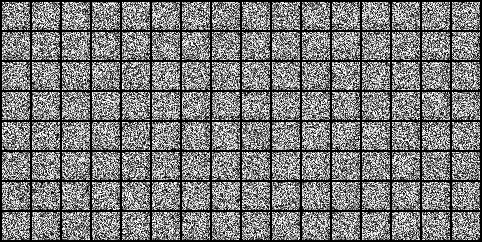

iter: 10


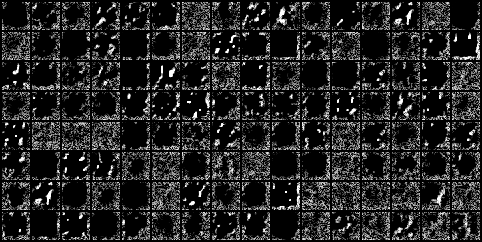

iter: 20


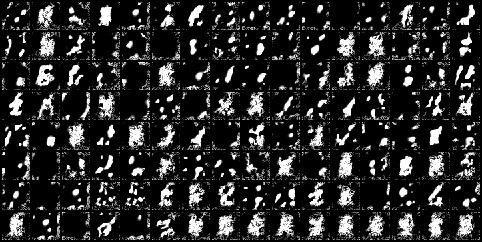

iter: 30


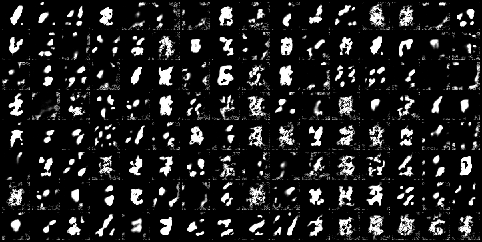

iter: 40


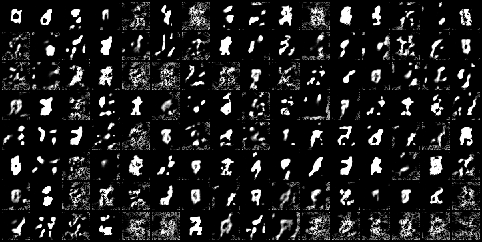

iter: 50


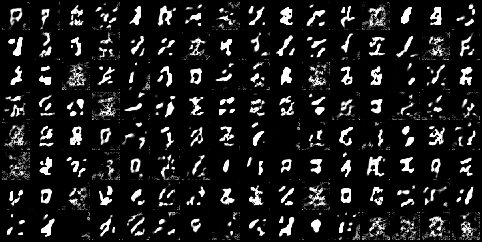

iter: 60


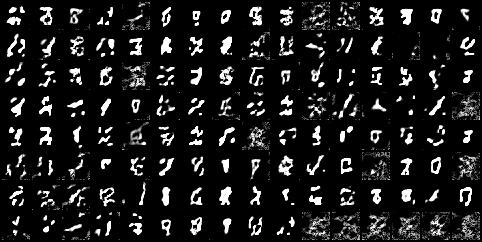

iter: 70


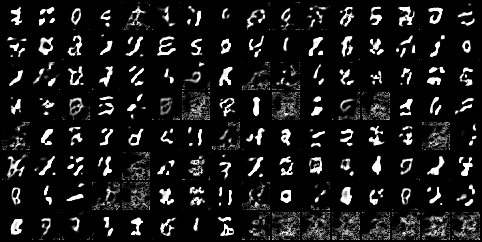

iter: 80


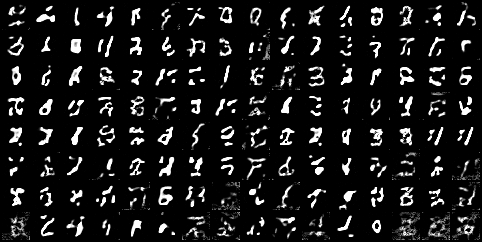

iter: 90


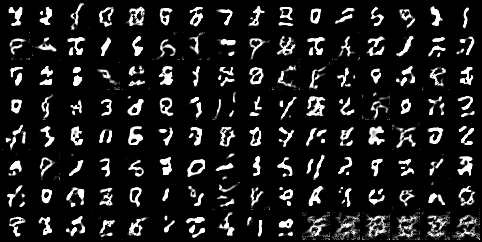

iter: 100


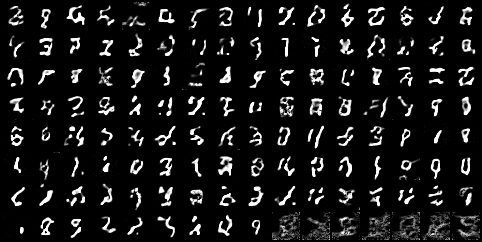

iter: 110


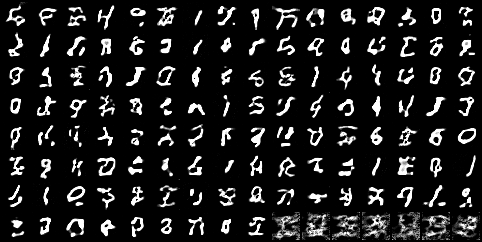

iter: 120


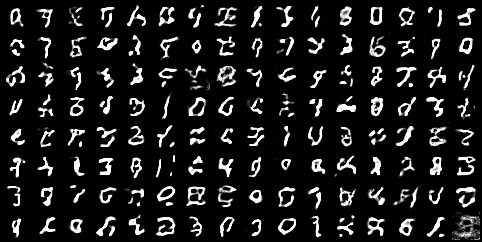

iter: 130


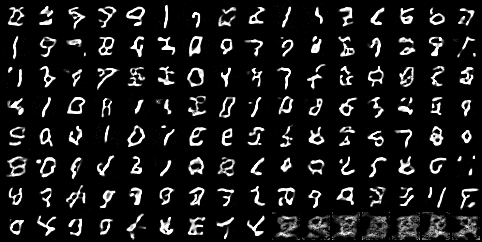

iter: 140


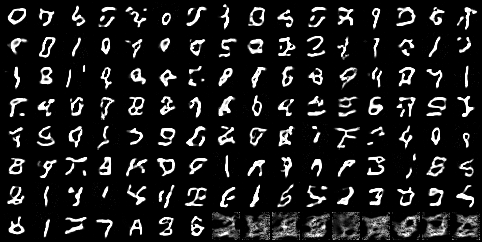

iter: 150


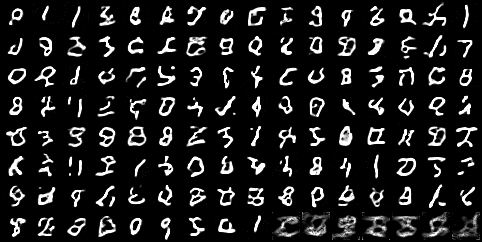

iter: 160


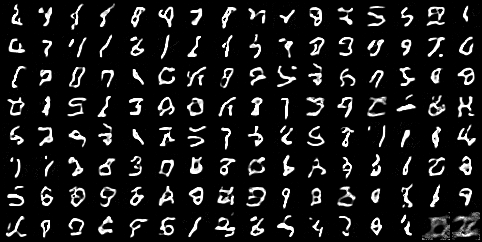

iter: 170


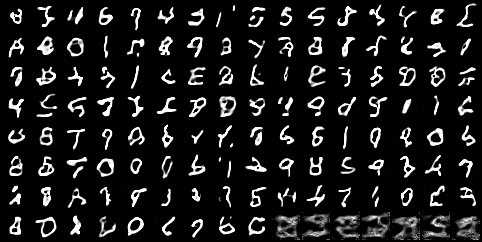

KeyboardInterrupt: 

In [3]:
# 今回はepoch毎に区切る必要がないので，無限にデータをロードできるようにする
def sample_data(loader):
    loader_iter = iter(loader)

    while True:
        try:
            yield next(loader_iter)

        except StopIteration:
            loader_iter = iter(loader)

            yield next(loader_iter)


# SGLD時にパラメータの勾配計算をoffにするのに用いる
def requires_grad(parameters, flag=True):
    for p in parameters:
        p.requires_grad = flag


# 論文のAppendix A.11に記載の通り、勾配をclipする ("we clip all training gradients that are more than 3 standard deviations from the 2nd order Adam parameters")
# 参考: Adamのアルゴリズム: https://docs.pytorch.org/docs/stable/generated/torch.optim.Adam.html
def clip_grad(parameters, optimizer):
    with torch.no_grad():
        for group in optimizer.param_groups:
            for p in group['params']:
                state = optimizer.state[p]

                if 'step' not in state or state['step'] < 1:
                    continue

                step = state['step']
                exp_avg_sq = state['exp_avg_sq']
                _, beta2 = group['betas']

                bound = 3 * torch.sqrt(exp_avg_sq / (1 - beta2 ** step)) + 0.1
                p.grad.data.copy_(torch.max(torch.min(p.grad.data, bound), -bound))


def train(model, alpha=1, step_size=10, sample_step=60, dataset_name='MNIST', device='cuda'):

    if dataset_name=='MNIST':
        dataset = datasets.MNIST('.', download=True, transform=transforms.ToTensor())
    elif dataset_name=='cifar10':
        dataset = datasets.CIFAR10('.', download=True, transform=transforms.ToTensor())
    loader = DataLoader(dataset, batch_size=128, shuffle=True, num_workers=4)
    loader = enumerate(sample_data(loader))

    image_size = dataset[0][0].size()

    buffer = SampleBuffer()

    noise = torch.randn(128, image_size[0], image_size[1], image_size[2], device=device)

    parameters = model.parameters()
    optimizer = optim.Adam(parameters, lr=1e-4, betas=(0.0, 0.999))

    for i, (pos_img, pos_id) in loader:

        # 経験分布に基づくデータ（データセットのデータ）
        pos_img, pos_id = pos_img.to(device), pos_id.to(device)

        # SGLDで生成モデルに基づくデータを生成するための初期値
        neg_img, neg_id = sample_buffer(buffer, pos_img.shape[0], image_size=image_size)
        neg_img.requires_grad = True

        requires_grad(parameters, False)
        model.eval()

        # 確率的勾配ランジェバンダイナミクス
        for k in range(sample_step):

            noise = torch.randn(neg_img.shape[0], image_size[0], image_size[1], image_size[2], device=device)

            noise.normal_(0, 0.005)  # 乱数の定義
            neg_img.data.add_(noise.data)

            neg_out = model(neg_img, neg_id)
            neg_out.sum().backward()
            neg_img.grad.data.clamp_(-0.01, 0.01)  # 学習の安定化の為の勾配クリッピング

            neg_img.data.add_(-step_size, neg_img.grad.data)  # バックプロップによるneg_imageの更新

            neg_img.grad.detach_()
            neg_img.grad.zero_()

            neg_img.data.clamp_(0, 1)  # ピクセル値の0～1を保証

        neg_img = neg_img.detach()

        requires_grad(parameters, True)
        model.train()

        model.zero_grad()

        pos_out = model(pos_img, pos_id)
        neg_out = model(neg_img, neg_id)

        loss = # WRITE ME  # L2正則化項を導入
        loss = loss.mean()
        loss.backward()

        clip_grad(parameters, optimizer) # 学習安定化のための勾配クリッピング

        optimizer.step()

        buffer.push(neg_img, neg_id)

        if i % 10 == 0: # 生成画像を保存する
            os.makedirs(save_dir, exist_ok=True)
            utils.save_image(
                neg_img.detach().to('cpu'),
                os.path.join(save_dir, f'{str(i).zfill(5)}.png'),
                nrow=16,
                normalize=True,
                value_range=(0, 1),
            )
            print('iter: {0}'.format(i))
            display_png(Image(os.path.join(save_dir, f'{str(i).zfill(5)}.png')))


if __name__ == '__main__':
    # 用いるデータセットを選択する
    dataset_list = ['MNIST', 'cifar10']
    dataset_name = dataset_list[0]

    # 保存するディレクトリを指定
    save_dir = "outputs"

    model = IGEBM(10, dataset_name=dataset_name).to('cuda')
    train(model, dataset_name=dataset_name)

    # 学習にはかなり時間がかかる
    # 最低でもMNISTでは1時間程度、CIFAR10では数時間程度学習しないと、それらしい出力を得られない
    # 論文ではCIFAR10に対して2日間学習させている

### 生成画像 (NMIST 500iter)

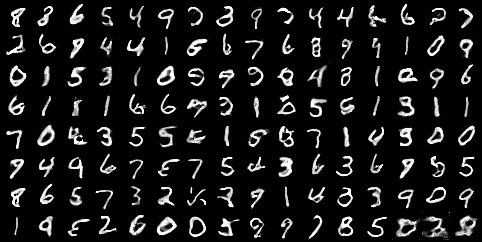

### 生成画像(CIFAR10 500iter)
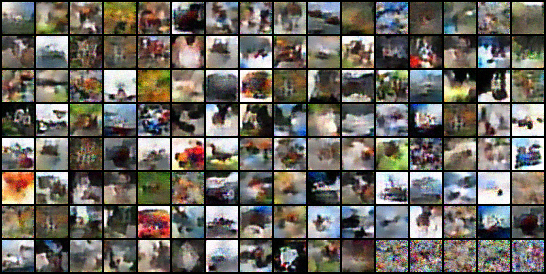